# 9. Analiza glavnih komponenti (PCA)

## Dimenzionalna redukcija

Postupak smanjenja broja atributa (dimenzija) u podacima, **uz zadržavanje što više
korisne informacije**.

Često imamo veliki broj atributa koji su **međusobno snažno korelisani** ili
**redundantni** — nose skoro istu informaciju.

**Klasičan primer:** dva atributa mere istu fizičku veličinu — dužina u centimetrima i
dužina u inčima. Podaci leže blizu prave linije, pa ih možemo opisati **jednom** dimenzijom.

### Šta se dobija

- kompresija podataka (manje memorije)
- brže izvršavanje algoritama učenja
- mogućnost **vizualizacije** (50D → 2D)
- uklanjanje redundantnih i korelisanih osobina
- uz **mali gubitak** informacije

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, load_digits, load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, train_test_split

plt.rcParams["figure.figsize"] = (9, 4.5); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = 42
rng = np.random.RandomState(RS)

# dva atributa koji mere istu stvar: duzina u cm i u incima
cm = rng.uniform(10, 60, 120)
inci = cm / 2.54 + rng.normal(0, 0.35, 120)
Xd = np.c_[cm, inci]
print(f"Korelacija dva atributa: {np.corrcoef(cm, inci)[0,1]:.4f}  <- skoro savrsena")

Korelacija dva atributa: 0.9983  <- skoro savrsena


## Prva glavna komponenta

**Pravac najveće varijanse** (principal direction) je pravac duž koga projekcija podataka
ima **maksimalnu varijansu**. U PCA se naziva **prva glavna komponenta (PC1)**.

Svaki podatak $x^{(i)}$ projektujemo na taj pravac i umesto dva broja dobijamo jedan:

$$x^{(i)} \in \mathbb{R}^2 \longrightarrow z^{(i)} \in \mathbb{R}$$

## Projekciona greška

**Projekciona greška** je **ortogonalno** (najkraće) rastojanje između originalne tačke i
njene projekcije na izabrani pravac. PCA uvek koristi normalnu (90°) projekciju.

> PCA traži pravac $u^{(1)}$ takav da **zbir kvadrata projekcionih grešaka bude minimalan** —
> odnosno pravac na koji projekcija „najmanje kvari" originalne podatke.

Napomena: ako PCA vrati vektor $u^{(1)}$ ili njegov negativ $-u^{(1)}$, to je **isto rešenje** —
oba definišu istu liniju u prostoru.

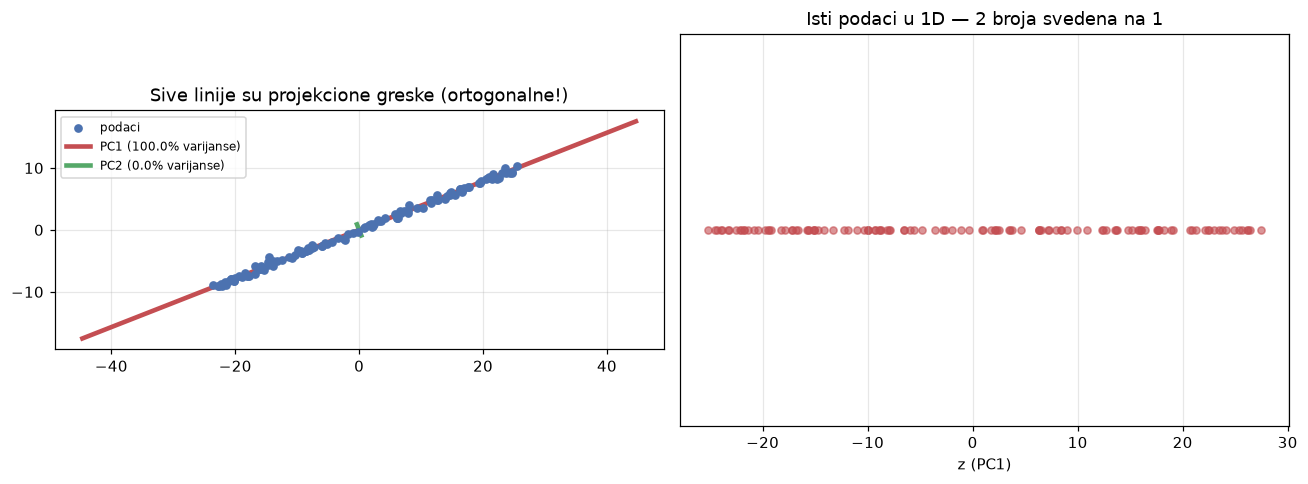

PC1 objasnjava 99.96% varijanse
PC2 objasnjava 0.04%  -> moze se odbaciti


In [2]:
Xc = Xd - Xd.mean(axis=0)                       # centriranje
pca2 = PCA(n_components=2).fit(Xc)
pc1 = pca2.components_[0]

Z1 = Xc @ pc1                                    # projekcija na PC1
proj = np.outer(Z1, pc1)                         # nazad u 2D

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(Xc[:, 0], Xc[:, 1], s=22, color="#4C72B0", label="podaci", zorder=3)
duz = 3 * np.sqrt(pca2.explained_variance_)
for i, (v, d, boja) in enumerate(zip(pca2.components_, duz, ["#C44E52", "#55A868"])):
    ax[0].plot([-v[0]*d, v[0]*d], [-v[1]*d, v[1]*d], color=boja, lw=3,
               label=f"PC{i+1} ({pca2.explained_variance_ratio_[i]:.1%} varijanse)")
for p, q in zip(Xc[:40], proj[:40]):
    ax[0].plot([p[0], q[0]], [p[1], q[1]], color="gray", lw=0.8, alpha=0.7)
ax[0].set_aspect("equal"); ax[0].legend(fontsize=8)
ax[0].set_title("Sive linije su projekcione greske (ortogonalne!)")

ax[1].scatter(Z1, np.zeros_like(Z1), s=22, color="#C44E52", alpha=0.6)
ax[1].set_yticks([]); ax[1].set_xlabel("z (PC1)")
ax[1].set_title("Isti podaci u 1D — 2 broja svedena na 1")
plt.tight_layout(); plt.show()

print(f"PC1 objasnjava {pca2.explained_variance_ratio_[0]:.2%} varijanse")
print(f"PC2 objasnjava {pca2.explained_variance_ratio_[1]:.2%}  -> moze se odbaciti")

## PCA nije linearna regresija

Na prvi pogled slično — obe metode traže pravu i minimizuju neku grešku. Ali su
**suštinski različite**:

| | linearna regresija | PCA |
|---|---|---|
| ciljna promenljiva $y$ | **postoji**, posebna je | **ne postoji**, sve osobine su ravnopravne |
| šta se minimizuje | **vertikalna** greška $y - \hat y$ | **ortogonalna** (projekciona) greška |
| cilj | predvideti $y$ | naći potprostor koji čuva najviše varijanse |

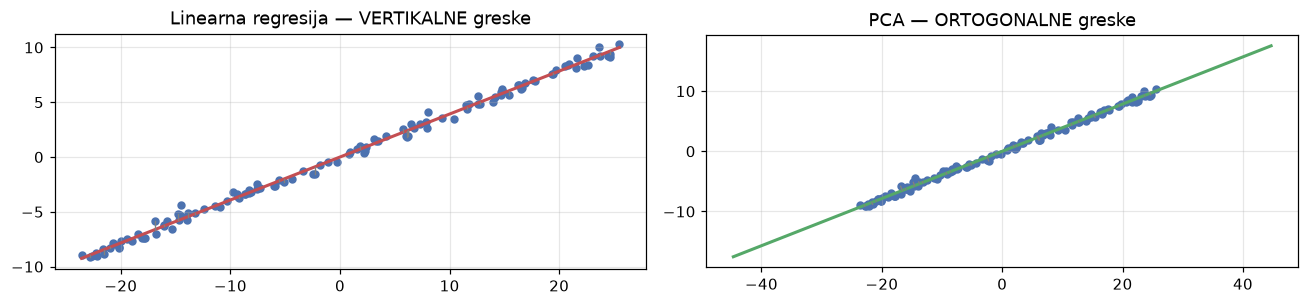

In [3]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression().fit(Xc[:, [0]], Xc[:, 1])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
xx = np.linspace(Xc[:, 0].min(), Xc[:, 0].max(), 50)

ax[0].scatter(Xc[:, 0], Xc[:, 1], s=20, color="#4C72B0")
ax[0].plot(xx, lr.predict(xx.reshape(-1, 1)), color="#C44E52", lw=2)
for p in Xc[:30]:
    ax[0].plot([p[0], p[0]], [p[1], lr.predict([[p[0]]])[0]], color="gray", lw=0.9)
ax[0].set_title("Linearna regresija — VERTIKALNE greske")

ax[1].scatter(Xc[:, 0], Xc[:, 1], s=20, color="#4C72B0")
ax[1].plot([-pc1[0]*duz[0], pc1[0]*duz[0]], [-pc1[1]*duz[0], pc1[1]*duz[0]], color="#55A868", lw=2)
for p, q in zip(Xc[:30], proj[:30]):
    ax[1].plot([p[0], q[0]], [p[1], q[1]], color="gray", lw=0.9)
ax[1].set_title("PCA — ORTOGONALNE greske")
for a in ax: a.set_aspect("equal")
plt.tight_layout(); plt.show()

## Pretprocesiranje — obavezan korak

Pre PCA podaci se **moraju** pripremiti, inače komponente budu besmislene.

**1. Mean normalization** (centriranje):
$$\mu_j = \frac{1}{m}\sum_{i=1}^{m} x_j^{(i)}, \qquad x_j^{(i)} \leftarrow x_j^{(i)} - \mu_j$$
Posle ovog koraka svaka osobina ima srednju vrednost 0.

**2. Feature scaling:**
$$x_j^{(i)} \leftarrow \frac{x_j^{(i)} - \mu_j}{s_j}$$
gde je $s_j$ mera raspona (najčešće standardna devijacija).

> **Zašto je obavezno:** PCA traži pravce **najveće varijanse**. Bez skaliranja, osobine sa
> velikim numeričkim vrednostima automatski imaju najveću varijansu i **dominiraju** —
> rezultat je pogrešna glavna komponenta.

In [4]:
bc = load_breast_cancer()
Xb = bc.data

pca_bez = PCA(n_components=5).fit(Xb)
pca_sa = PCA(n_components=5).fit(StandardScaler().fit_transform(Xb))

print("Varijansa originalnih atributa (5 najvecih):")
var = pd.Series(Xb.var(axis=0), index=bc.feature_names).sort_values(ascending=False)
print(var.head(5).round(1).to_string())

print(f"\nBEZ skaliranja — PC1 objasnjava {pca_bez.explained_variance_ratio_[0]:.2%}")
dom = np.abs(pca_bez.components_[0]).argmax()
print(f"   PC1 najvise zavisi od: '{bc.feature_names[dom]}' (varijansa {Xb[:,dom].var():.0f})")
print(f"\nSA skaliranjem — PC1 objasnjava {pca_sa.explained_variance_ratio_[0]:.2%}")
print(f"   -> Bez skaliranja PC1 je samo najveci atribut, ne prava struktura.")

Varijansa originalnih atributa (5 najvecih):
worst area         323597.7
mean area          123625.9
area error           2065.8
worst perimeter      1127.1
mean perimeter        589.4

BEZ skaliranja — PC1 objasnjava 98.20%
   PC1 najvise zavisi od: 'worst area' (varijansa 323598)

SA skaliranjem — PC1 objasnjava 44.27%
   -> Bez skaliranja PC1 je samo najveci atribut, ne prava struktura.


## Algoritam PCA

**Korak 1 — matrica kovarijanse.** Nad centriranim (i skaliranim) podacima:

$$\Sigma = \frac{1}{m}\sum_{i=1}^{m} x^{(i)} \big(x^{(i)}\big)^\top$$

$\Sigma$ je dimenzije $n \times n$ i opisuje kako su osobine međusobno povezane.

**Korak 2 — glavne komponente preko SVD.** Na $\Sigma$ se primenjuje **Singular Value
Decomposition**, koji vraća matricu $U$.

| pojam | značenje |
|---|---|
| **eigenvektor** | pravac glavne komponente |
| **eigenvrednost** | količina varijanse u tom pravcu |

SVD vraća komponente **već sortirane** po važnosti.

**Korak 3 — smanjenje dimenzije.** Zadržavamo prvih $k$ kolona:
$$U_{\text{reduce}} = \big[u^{(1)}, \dots, u^{(k)}\big] \in \mathbb{R}^{n \times k}$$

**Korak 4 — projekcija:**
$$z^{(i)} = U_{\text{reduce}}^\top \, x^{(i)} \in \mathbb{R}^{k}$$

In [5]:
iris = load_iris()
Xi = StandardScaler().fit_transform(iris.data)

# --- rucno, korak po korak ---
Sigma = np.cov(Xi, rowvar=False)                          # korak 1
U, S, Vt = np.linalg.svd(Sigma)                           # korak 2
U_reduce = U[:, :2]                                       # korak 3
Z_rucno = Xi @ U_reduce                                   # korak 4

# --- sklearn ---
Z_sk = PCA(n_components=2).fit_transform(Xi)

print(f"Matrica kovarijanse Sigma: {Sigma.shape}")
print(f"Eigenvrednosti (varijansa po pravcu): {S.round(3)}")
print(f"Udeo varijanse: {(S/S.sum()).round(4)}")
print(f"\nRucno i sklearn daju isto (do znaka): "
      f"{np.allclose(np.abs(Z_rucno), np.abs(Z_sk))}")

Matrica kovarijanse Sigma: (4, 4)
Eigenvrednosti (varijansa po pravcu): [2.938 0.92  0.148 0.021]
Udeo varijanse: [0.7296 0.2285 0.0367 0.0052]

Rucno i sklearn daju isto (do znaka): True


## Kako birati broj komponenti $K$

U praksi se **ne bira $K$ direktno**, već **procenat zadržane varijanse**.

Najčešće vrednosti: **95%** ili **99%**.

U `scikit-learn`:
- `PCA(n_components=k)` — zadržava tačno $k$ dimenzija
- `PCA(n_components=0.95)` — zadržava onoliko komponenti koliko treba za **95% varijanse**

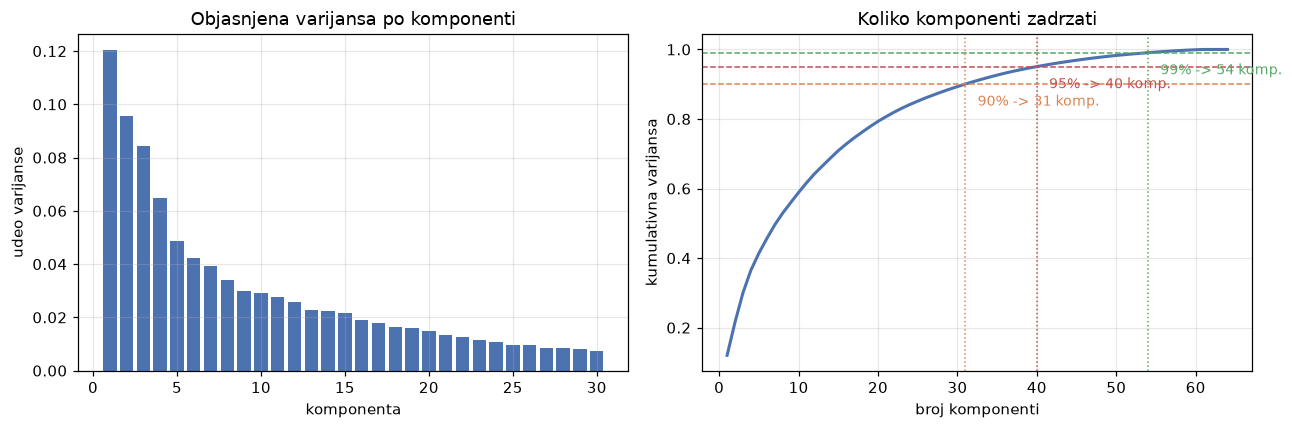

Originalno dimenzija: 64
   za 90% varijanse potrebno: 31 komponenti
   za 95% varijanse potrebno: 40 komponenti
   za 99% varijanse potrebno: 54 komponenti


In [6]:
digits = load_digits()
Xg = StandardScaler().fit_transform(digits.data)

pca_pun = PCA().fit(Xg)
kum = np.cumsum(pca_pun.explained_variance_ratio_)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(1, 31), pca_pun.explained_variance_ratio_[:30], color="#4C72B0")
ax[0].set_xlabel("komponenta"); ax[0].set_ylabel("udeo varijanse")
ax[0].set_title("Objasnjena varijansa po komponenti")

ax[1].plot(range(1, len(kum)+1), kum, lw=2, color="#4C72B0")
for prag, boja in [(0.90, "#DD8452"), (0.95, "#C44E52"), (0.99, "#55A868")]:
    k = int(np.argmax(kum >= prag)) + 1
    ax[1].axhline(prag, color=boja, ls="--", lw=1)
    ax[1].axvline(k, color=boja, ls=":", lw=1)
    ax[1].annotate(f"{prag:.0%} -> {k} komp.", (k, prag), fontsize=9,
                   xytext=(8, -14), textcoords="offset points", color=boja)
ax[1].set_xlabel("broj komponenti"); ax[1].set_ylabel("kumulativna varijansa")
ax[1].set_title("Koliko komponenti zadrzati")
plt.tight_layout(); plt.show()

print(f"Originalno dimenzija: {Xg.shape[1]}")
for p in (0.90, 0.95, 0.99):
    print(f"   za {p:.0%} varijanse potrebno: {int(np.argmax(kum >= p))+1} komponenti")

## Vizualizacija visokodimenzionalnih podataka

Jedna od najkorisnijih primena: podatke u 50 ili 64 dimenzije ne možemo direktno
vizualizovati. PCA ih mapira u 2D i time omogućava da vidimo strukturu.

> **Važno:** ose $z_1$ i $z_2$ **nemaju unapred definisano značenje**. PCA ne zna šta je
> koji atribut — on samo pronalazi pravce najveće varijanse. **Značenje osama tumačimo
> naknadno**, mi ljudi.

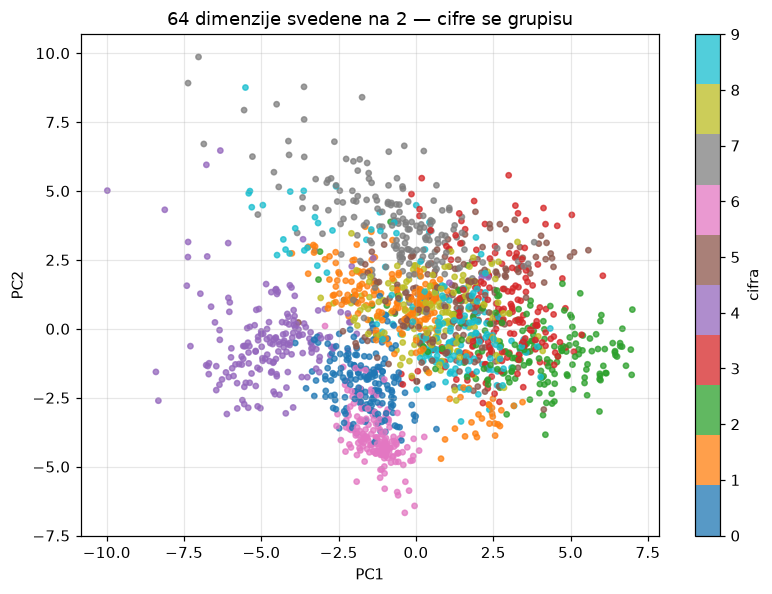

In [7]:
Z = PCA(n_components=2).fit_transform(Xg)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
s = ax.scatter(Z[:, 0], Z[:, 1], c=digits.target, s=12, cmap="tab10", alpha=0.75)
plt.colorbar(s, label="cifra")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("64 dimenzije svedene na 2 — cifre se grupisu")
plt.tight_layout(); plt.show()

## PCA u praksi — sklearn i česta greška

```python
pca = PCA(n_components=2)
Z = pca.fit_transform(X)

pca.explained_variance_ratio_          # udeo varijanse po komponenti
pca.explained_variance_ratio_.sum()    # ukupna zadrzana varijansa
pca.components_                        # matrica U^T (pravci komponenti)
```

> **Česta greška:** na test skupu se poziva `fit_transform`. To je **data leakage** —
> PCA bi naučila pravce iz test podataka.
> Ispravno: `fit_transform(X_train)` i **samo** `transform(X_test)`.

Najsigurnije je koristiti `Pipeline`.

In [8]:
Xtr, Xte, ytr, yte = train_test_split(digits.data, digits.target, test_size=0.3,
                                      random_state=RS, stratify=digits.target)
print(f"{'broj komponenti':>18} {'tacnost':>9} {'dimenzija':>11}")
print("-" * 42)
for k in (2, 5, 10, 20, 40, 0.95, None):
    if k is None:
        pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
        opis, dim = "bez PCA", Xtr.shape[1]
    else:
        pipe = make_pipeline(StandardScaler(), PCA(n_components=k),
                             LogisticRegression(max_iter=3000))
        opis = f"{k:.0%} varijanse" if isinstance(k, float) else str(k)
        dim = "-"
    pipe.fit(Xtr, ytr)
    if k is not None:
        dim = pipe.named_steps["pca"].n_components_
    print(f"{opis:>18} {pipe.score(Xte, yte):>9.4f} {str(dim):>11}")

   broj komponenti   tacnost   dimenzija
------------------------------------------
                 2    0.5278           2


                 5    0.8000           5
                10    0.8796          10
                20    0.9463          20
                40    0.9648          40
     95% varijanse    0.9630          39
           bez PCA    0.9815          64


## Rekonstrukcija podataka

Iz kompresovane reprezentacije možemo približno vratiti originalne podatke:

$$x_{\text{approx}}^{(i)} = U_{\text{reduce}} \, z^{(i)}$$

Rezultat **nije identičan** originalu — razlika je upravo **projekciona greška**.

> PCA ne pamti originalne tačke, već njihovu **najbolju aproksimaciju** u izabranom
> potprostoru.

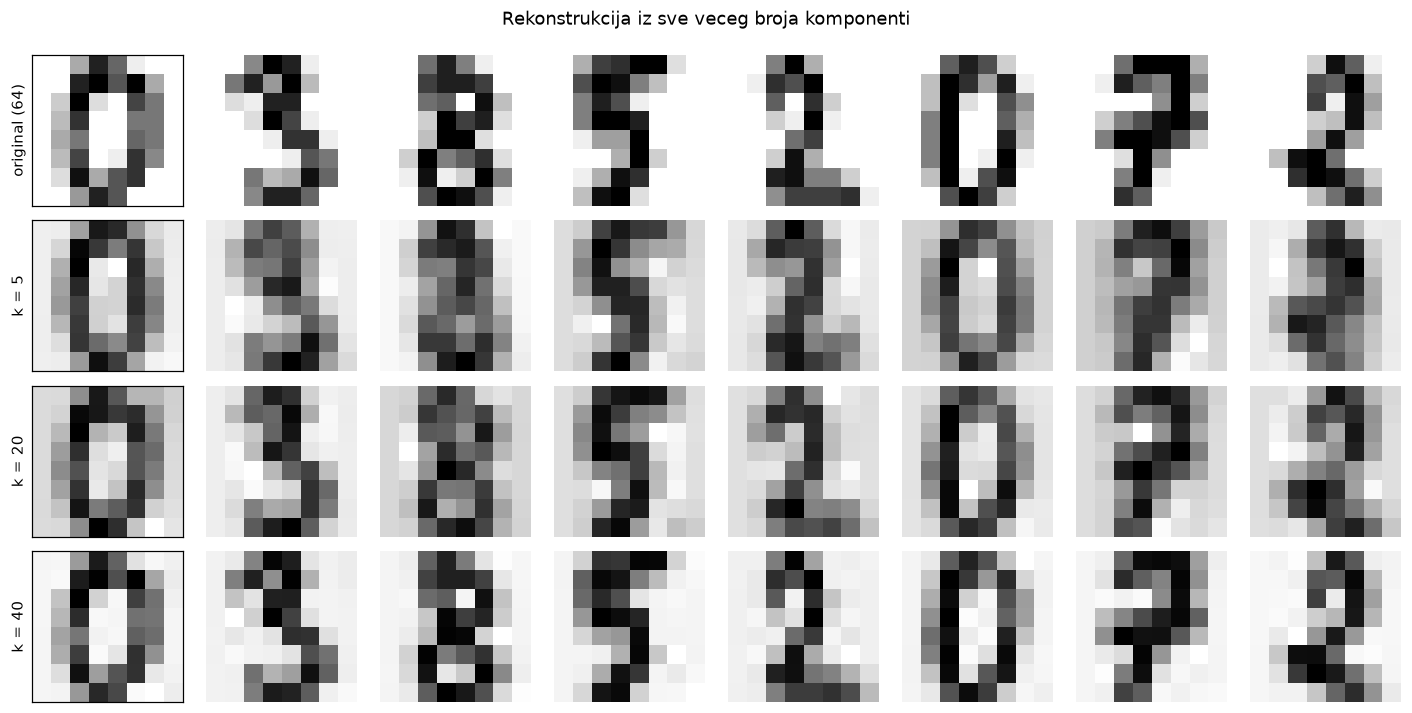

k =  5: zadrzano 54.5% varijanse, greska rekonstrukcije 8.54
k = 20: zadrzano 89.4% varijanse, greska rekonstrukcije 1.98
k = 40: zadrzano 98.8% varijanse, greska rekonstrukcije 0.22


In [9]:
fig, ax = plt.subplots(4, 8, figsize=(13, 6.5))
uzorci = [0, 3, 8, 15, 22, 30, 44, 51]
for j, i in enumerate(uzorci):
    ax[0, j].imshow(digits.images[i], cmap="gray_r"); ax[0, j].axis("off")
for red, k in enumerate((5, 20, 40), start=1):
    p = PCA(n_components=k).fit(digits.data)
    rek = p.inverse_transform(p.transform(digits.data))
    for j, i in enumerate(uzorci):
        ax[red, j].imshow(rek[i].reshape(8, 8), cmap="gray_r"); ax[red, j].axis("off")
for red, t in enumerate(["original (64)", "k = 5", "k = 20", "k = 40"]):
    ax[red, 0].set_ylabel(t)
    ax[red, 0].axis("on"); ax[red, 0].set_xticks([]); ax[red, 0].set_yticks([])
plt.suptitle("Rekonstrukcija iz sve veceg broja komponenti", y=0.99)
plt.tight_layout(); plt.show()

for k in (5, 20, 40):
    p = PCA(n_components=k).fit(digits.data)
    greska = np.mean((digits.data - p.inverse_transform(p.transform(digits.data))) ** 2)
    print(f"k = {k:>2}: zadrzano {p.explained_variance_ratio_.sum():.1%} varijanse, "
          f"greska rekonstrukcije {greska:.2f}")